# EGFR KD Analysis
This notebook loads all the summary CSVs, merges them with a dataset column, and plots a grid of KD value histograms.

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import gmean
import re

path_std = '/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/EGFR_round5/EGFR_test_all_rounds_summary.csv'
path_comp = '/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/EGFR_round5_comptbuffer/EGFR_test_all_rounds (Competition Buffer)_summary.csv'
path_fasta = '/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_finalresults_december/submission_fasta_adaptyv_rounds.txt'

df_std = pd.read_csv(path_std)
df_comp = pd.read_csv(path_comp)

df_std['buffer'] = 'standard'
df_comp['buffer'] = 'compbuffer'
df_all = pd.concat([df_std, df_comp], ignore_index=True)

# 2. Parse FASTA for the name mapping
fasta_names = {}
with open(path_fasta, 'r') as f:
    current_name = ""
    for line in f:
        line = line.strip()
        if line.startswith('>'):
            current_name = line[1:]
        elif line:
            fasta_names[line] = current_name

df_fasta = pd.DataFrame(list(fasta_names.items()), columns=['sequence', 'fasta_name'])

# 3. Merge and identify Round/Control/WT
df_final = df_all.merge(df_fasta, on='sequence', how='left')

def identify_round(text):
    if pd.isna(text): return "unknown"
    text_str = str(text).lower()
    
    # Check for round pattern (e.g., round_2, round_3.3)
    match = re.search(r'round_([\d\.]+)', text_str)
    if match:
        return f"round_{match.group(1)}"
    
    # Check for WT or Control keywords
    if 'wt' in text_str:
        return 'WT'
    if 'ctrl' in text_str or 'control' in text_str:
        return 'control'
    
    # Return the original text if no pattern found (preserves generic names)
    return text

# Assign the round label based on the name found in the txt (or csv name as fallback)
df_final['round'] = df_final['fasta_name'].fillna(df_final['name']).apply(identify_round)

# 4. Calculate Geometric Average across replicates
def geo_mean(x):
    # Filter for positive values to avoid errors with gmean
    clean_x = x.dropna()[x > 0]
    return gmean(clean_x) if not clean_x.empty else np.nan

# Group by sequence and buffer
avg_df_pub = df_final.groupby(['sequence', 'buffer']).agg({
    'round': 'first',
    'koff': geo_mean,
    'kon': geo_mean,
    'kd': geo_mean,
    'expression': 'first',
    'confidence': 'first'
}).reset_index()

# 5. Final output with specific columns
avg_df_pub = avg_df_pub[["round", "koff", "kon", "kd", "sequence", "expression", "confidence", "buffer"]]

avg_df_pub.loc[
    avg_df_pub["sequence"] == "SNTVQRCPSSHDAYCLYGGVCFYIPEMESFACKCVKGFVGERCQFSDLEWWE",
    "round"
] = "round_2"


# Save the final dataframe
avg_df_pub.to_csv('EGFR_test_summary_avg.csv', index=False)

print("Processing complete. Created 'EGFR_test_summary_avg.csv' with columns:")
print(avg_df_pub.columns.tolist())

Processing complete. Created 'EGFR_test_summary_avg.csv' with columns:
['round', 'koff', 'kon', 'kd', 'sequence', 'expression', 'confidence', 'buffer']


In [4]:
import glob
import os

# 6. Load other rounds, extracting the Round label from the file path
base_dir = '/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/'
all_csvs = glob.glob(os.path.join(base_dir, "**/EGFR_round*/*_summary.csv"), recursive=True)

others = []
for f in all_csvs:
    if 'round5' in f.lower(): continue  # Skip the trusted Round 5 data
    
    tmp = pd.read_csv(f)
    tmp['buffer'] = 'compbuffer' if 'compt' in f.lower() else 'standard'
    
    # Extract round from folder name (e.g., EGFR_round3.3 -> round_3.3)
    match = re.search(r'round([\d\.]+)', f.lower())
    tmp['round'] = f"round_{match.group(1)}" if match else "unknown"
    
    # Filter: Keep only sequences NOT re-tested in Round 5
    tmp = tmp[~tmp['sequence'].isin(avg_df_pub['sequence'])]
    
    if not tmp.empty:
        others.append(tmp)

if others:
    # Average replicates and append the non-binders/older sequences
    avg_others = pd.concat(others).groupby(['sequence', 'buffer'], as_index=False).agg({
        'round': 'first', # Taken from the folder/file path
        'koff': geo_mean, 
        'kon': geo_mean, 
        'kd': geo_mean, 
        'expression': 'first', 
        'confidence': 'first'
    })
    avg_df_pub = pd.concat([avg_df_pub, avg_others[avg_df_pub.columns]], ignore_index=True)

# Save final consolidated dataframe
avg_df_pub.to_csv('EGFR_test_summary_avg.csv', index=False)

In [5]:
avg_df_pub["round"].unique()

<StringArray>
['round_3.3', 'round_3.1', 'WT', 'control', 'round_2', 'round_1', 'round_3.2']
Length: 7, dtype: str

In [6]:
# Print table for publication: 

avg_df_pub= avg_df_pub[["round","koff", "kon", "kd", "sequence", "expression","confidence", "buffer"]]


def sci_tex(x, sig=2):
    if pd.isna(x):
        return ""
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"${mant:.{sig}f}\times 10^{{{exp}}}$"

cols_sci = ["kd", "kon", "koff"]
formatters = {c: (lambda v, c=c: sci_tex(v, sig=2)) for c in cols_sci}

latex = avg_df_pub.to_latex(
    longtable=True,
    index=False,
    formatters=formatters,
    na_rep="-",
    caption="test",
    label="test",
    escape=False,       # IMPORTANT so \times prints correctly

)
print(latex)

\begin{longtable}{lrrrllll}
\caption{test} \label{test} \\
\toprule
round & koff & kon & kd & sequence & expression & confidence & buffer \\
\midrule
\endfirsthead
\caption[]{test} \\
\toprule
round & koff & kon & kd & sequence & expression & confidence & buffer \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
round_3.3 & $9.88\times 10^{-3}$ & $1.60\times 10^{5}$ & $6.17\times 10^{-8}$ & GNSECPTSHADFCLNNGICIYIEKVDRYACKCVVGYIGERCQFSDLEWWE & high & high & compbuffer \\
round_3.3 & $3.72\times 10^{-3}$ & $1.55\times 10^{5}$ & $2.40\times 10^{-8}$ & GNSECPTSHADFCLNNGICIYIEKVDRYACKCVVGYIGERCQFSDLEWWE & medium & high & standard \\
round_3.1 & $2.10\times 10^{-1}$ & $6.77\times 10^{4}$ & $3.09\times 10^{-6}$ & NPSDSVAGSTRPGLAEPCPMEYYSPYCLHGECKFIKELSSYACNCVKGYLGERCEFSDLEWWE & high & low & compbuffer \\
round_3.1 & $1.33\times 10^{-2}$ & $1.81\times 10^{4}$ & $7.35\times 10^{-7}$ & NPSDSVAGSTRPGLAEPCPMEYYSPYCLHGECKFIKELSSYAC

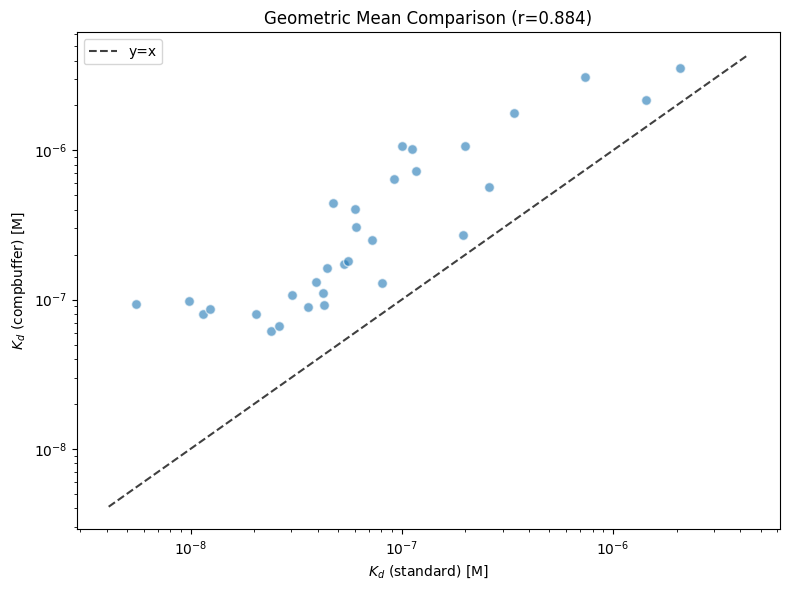

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the processed average data
df_comp = pd.read_csv('/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/EGFR_round5_comptbuffer/EGFR_test_all_rounds (Competition Buffer)_summary.csv')
df_std = pd.read_csv('/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/EGFR_round5/EGFR_test_all_rounds_summary.csv')

# Compute geometric mean of 'kd' by 'sequence' for both conditions
def geometric_mean(series):
    return np.exp(np.log(series).mean())

# Group by sequence and calculate geometric mean for each condition
df_std_geom = df_std.groupby('sequence')['kd'].apply(geometric_mean).reset_index(name='kd_std')
df_comp_geom = df_comp.groupby('sequence')['kd'].apply(geometric_mean).reset_index(name='kd_comp')

# Merge the geometric means
merged_df = pd.merge(df_std_geom, df_comp_geom, on='sequence')

# Drop NaNs if any
merged_df = merged_df.dropna()

# Calculate Pearson correlation on the log10 scale for both kd columns
x = np.log10(merged_df['kd_std'].to_numpy())
y = np.log10(merged_df['kd_comp'].to_numpy())
correlation = np.corrcoef(x, y)[0, 1]

# Plotting the correlation
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['kd_std'], merged_df['kd_comp'], alpha=0.6, edgecolors='w', s=50)
plt.xscale("log")
plt.yscale("log")

# Add a y=x line for reference
lims = [
    np.min([plt.xlim()[0], plt.ylim()[0]]),
    np.max([plt.xlim()[1], plt.ylim()[1]]),
]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x')

plt.xlabel("$K_d$ (standard) [M]")
plt.ylabel("$K_d$ (compbuffer) [M]")
plt.title(f"Geometric Mean Comparison (r={correlation:.3f})")
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

# Optionally save the plot
plt.savefig("plots/corr_geom_mean_std_compbuffer.png", dpi=300)

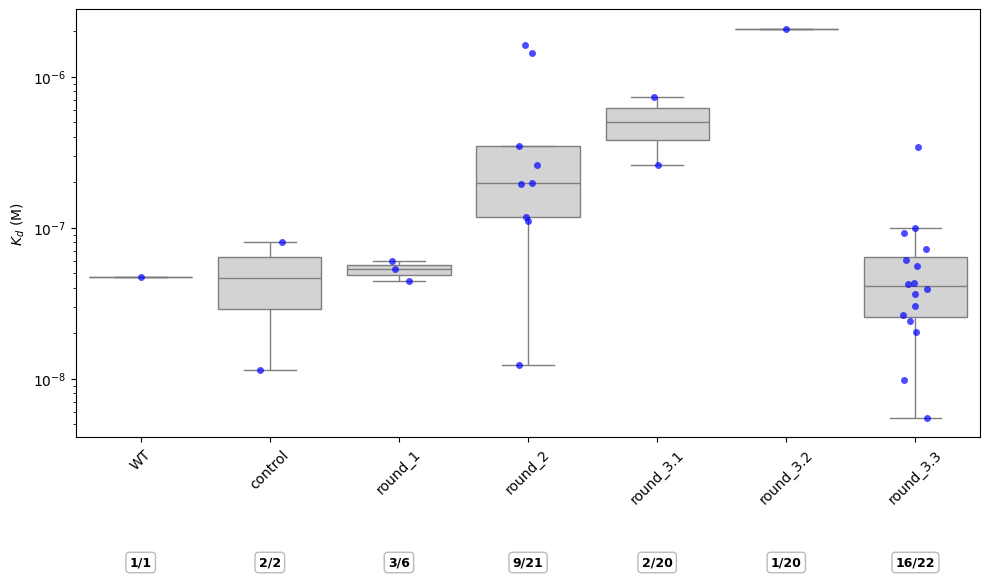

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Load the processed summary data
df = pd.read_csv('EGFR_test_summary_avg.csv')

# Define a function to sort rounds naturally
def sort_key(round_str):
    if round_str == 'WT': return 0
    if round_str == 'control': return 1
    match = re.search(r'round_([\d\.]+)', str(round_str))
    if match:
        return 2 + float(match.group(1))
    return 99

# Filter for standard buffer
df_std = df[df["buffer"] == "standard"].copy()

# Get unique rounds and sort them
rounds = sorted(df_std["round"].unique(), key=sort_key)

# Calculate counts for each round
stats = {}
for r_val in rounds:
    round_data = df_std[df_std["round"] == r_val]
    total_count = len(round_data)
    expressed_count = round_data["kd"].notna().sum()
    stats[r_val] = {'expr': expressed_count, 'total': total_count}

# Create figure
plt.figure(figsize=(10, 6))

# Boxplot showing KD distribution
sns.boxplot(
    data=df_std, 
    x="round", 
    y="kd", 
    order=rounds,
    color="lightgray", 
    showfliers=False
)

# Overlay data points
sns.stripplot(
    data=df_std, 
    x="round", 
    y="kd", 
    order=rounds,
    color="blue", 
    jitter=True, 
    size=5, 
    alpha=0.7
)

# Annotate with expressed / total numbers
# Determine a safe Y position at the bottom of the log scale
ymin = df_std["kd"].min()
text_y = ymin * 0.1 if not pd.isna(ymin) else 1e-11

for i, r_val in enumerate(rounds):
    s = stats[r_val]
    
    if r_val == "round_1":
        label = f"{"3/6"}" # Format as "expressed/total"
    else:
        label = f"{s['expr']}/{s['total']}" # Format as "expressed/total"

    plt.text(
        i, text_y, label, ha="center", va="bottom", fontsize=9, color="black", 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
    )

# Formatting
plt.yscale("log")
plt.ylabel("$K_d$ (M)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()

# Save output
plt.savefig("plots/kd_changes_across_rounds.pdf", dpi=600)
plt.show()

/tmp/ipykernel_744852/1827501346.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", fontsize=10, frameon=False)


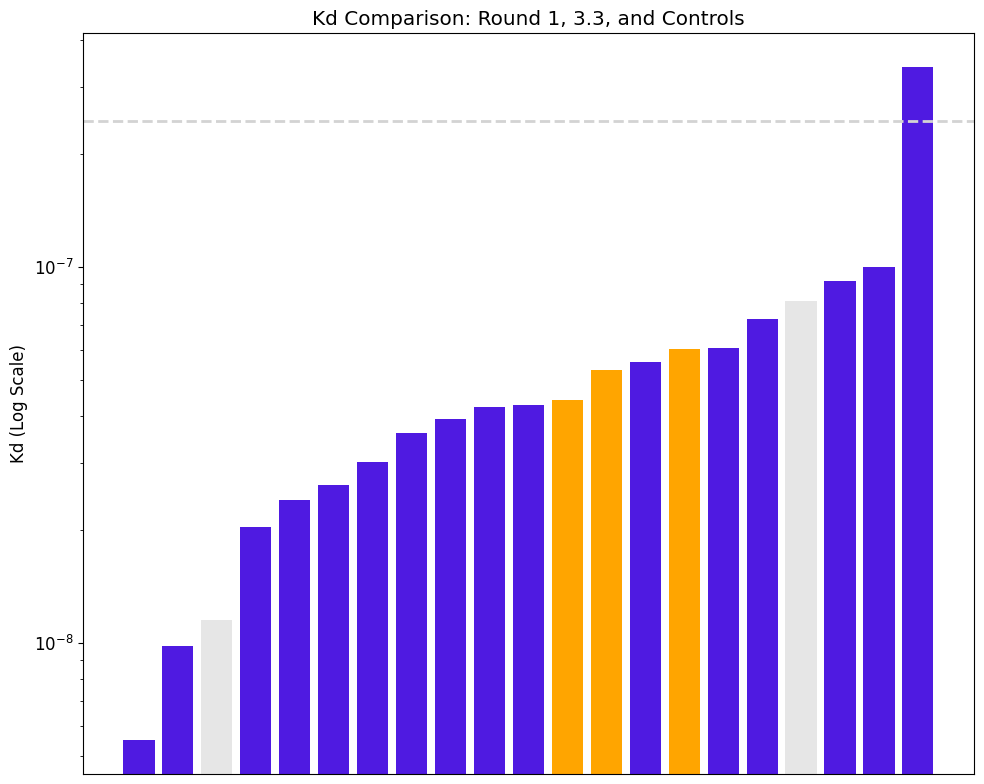

Done: sorted_kd_comparison_no_x_labels_first_10.png and sorted_kd_comparison_no_x_labels_first_10.pdf


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('EGFR_test_summary_avg.csv')
df["kd"] = pd.to_numeric(df["kd"], errors='coerce')
df = df.dropna(subset=["kd"])

# Filter for the standard buffer and relevant rounds
df_std = df[df["buffer"] == "compbuffer"]
df_std = df[df["buffer"] == "standard"]

df_filtered = df_std[df_std["round"].isin(["round_1", "round_3.3", "control"])]

# Sort by KD (from lowest to highest)
df_filtered = df_filtered.sort_values("kd", ascending=True)

# Take only the first 10 rows
df_filtered = df_filtered.head(21)

# WT KD
wt_kd = df[df["round"] == "WT"]["kd"].mean()

# Colors for rounds
colors = {"round_1": "#FFA500", "round_3.3": "#4F1AE1", "control": "#E6E6E6"}
df_filtered["color"] = df_filtered["round"].map(colors)

# Plotting
plt.figure(figsize=(10, 8))  # Make the plot more square
x = range(len(df_filtered))
plt.bar(x, df_filtered["kd"], color=df_filtered["color"], edgecolor="none")

# WT KD line
plt.axhline(y=wt_kd, color="lightgrey", linestyle="--", linewidth=2)

# Customize plot
plt.yscale("log")
plt.ylabel("Kd (Log Scale)")
plt.title("Kd Comparison: Round 1, 3.3, and Controls")
plt.xticks([])  # Remove x-axis labels

# Add the legend with linewidth 2
plt.legend(loc="upper right", fontsize=10, frameon=False)

plt.tight_layout()

# Save and show plot
plt.savefig("plots/sorted_kd_comparison_no_x_labels_first_10.png", dpi=600, bbox_inches="tight")
plt.savefig("plots/sorted_kd_comparison_no_x_labels_first_10.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("Done: sorted_kd_comparison_no_x_labels_first_10.png and sorted_kd_comparison_no_x_labels_first_10.pdf")

/tmp/ipykernel_950867/4268210064.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_filtered, x="round", y="kd", order=rounds_to_plot,


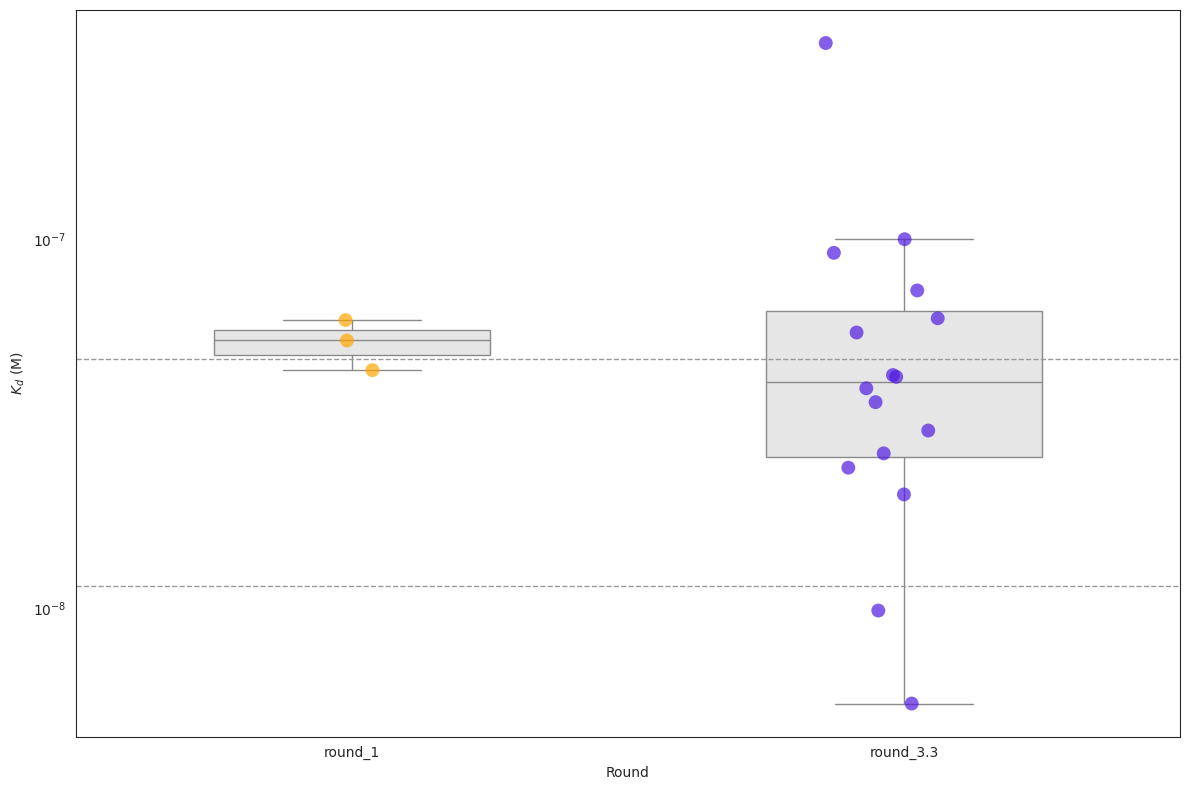

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
csv_file = "/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/EGFR_test_summary_avg.csv"
df = pd.read_csv(csv_file)

# 2. Filter for standard buffer and numeric Kd
df = df[df["buffer"] == "standard"].copy()
df["kd"] = pd.to_numeric(df["kd"], errors='coerce')

# 3. Find the specific control sequence Kd
target_seq = "NSDSECPLSHDGYCLHGGVCMYIKAVDRYACNCVVGYIGERCQYRDLTWWGPR"
target_kd = df[df["sequence"] == target_seq]["kd"].mean()

# 4. Prepare data for plotting (Round 1 vs 3.3)
wt_val = df[df["round"] == "WT"]["kd"].mean()
rounds_to_plot = ["round_1", "round_3.3"]
df_filtered = df[df["round"].isin(rounds_to_plot)].dropna(subset=["kd"])

# 5. Plotting
plt.figure(figsize=(12, 8))
sns.set_style("white")

# Boxplot + Stripplot
sns.boxplot(data=df_filtered, x="round", y="kd", order=rounds_to_plot, color="0.9", fliersize=0, width=0.5)
sns.stripplot(data=df_filtered, x="round", y="kd", order=rounds_to_plot,
              palette={"round_1": "#FFA500", "round_3.3": "#4F1AE1"},
              jitter=0.15, size=10, alpha=0.7)

# Add Reference Lines
if not pd.isna(wt_val):
    plt.axhline(y=wt_val, color="0.6", linestyle="--",linewidth=1, label="WT")

if not pd.isna(target_kd):
    plt.axhline(y=target_kd, color="0.6", linestyle="--", linewidth=1, label="Control Seq")

# Adjustments
plt.yscale("log")
plt.ylabel("$K_d$ (M)")
plt.xlabel("Round")
plt.tight_layout()

plt.savefig("plots/plot_round1_vs_3.3_with_control.pdf")
plt.show()

In [17]:
#print fasta for blast search round 3.3

csv_file = "/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/EGFR_test_summary_avg.csv"
df = pd.read_csv(csv_file)
df_filtered = df[df["round"].isin(["round_3.3"])]
out = ""
for idx,x in enumerate(set(df_filtered.sequence.to_list())):
    out += f">{idx}\n{x}\n"


In [ ]:
#print fasta for blast search round 3.3

csv_file = "/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/EGFR_test_summary_avg.csv"
df = pd.read_csv(csv_file)
df_filtered = df[df["round"].isin(["round_1"])]
out = ""
for idx,x in enumerate(set(df_filtered.sequence.to_list())):
    out += f">{idx}\n{x}\n"

print(out)

''' plus the one not binding
SKCPEDLTHYCIHGQCRYIKQQNAPSCRCQHGYIGSRCEYVDLDW
PENYKSCPPSHDGYCLHGGVCMYISALQAYACNCIQGFVGERCQHSDLEWWE
CPKEYVHFCIHGTCRFVQEQNTPSCRCESGYIGARCEYVDLDW
'''


>0
PENYKSCPPSHDGYCLHGGVCMYISALQAYACNCIQGFVGERCQHSDLEWWE
>1
PSTVESCPLSHEGYCLYEGVCFYFPEMESYACNCVSGYMGERCQFSDLEWLELQ
>2
PDTIASCPSSHESYCLYQGVCFYFPEMESYACNCVSGYMGERCQFSDLQWWELQ



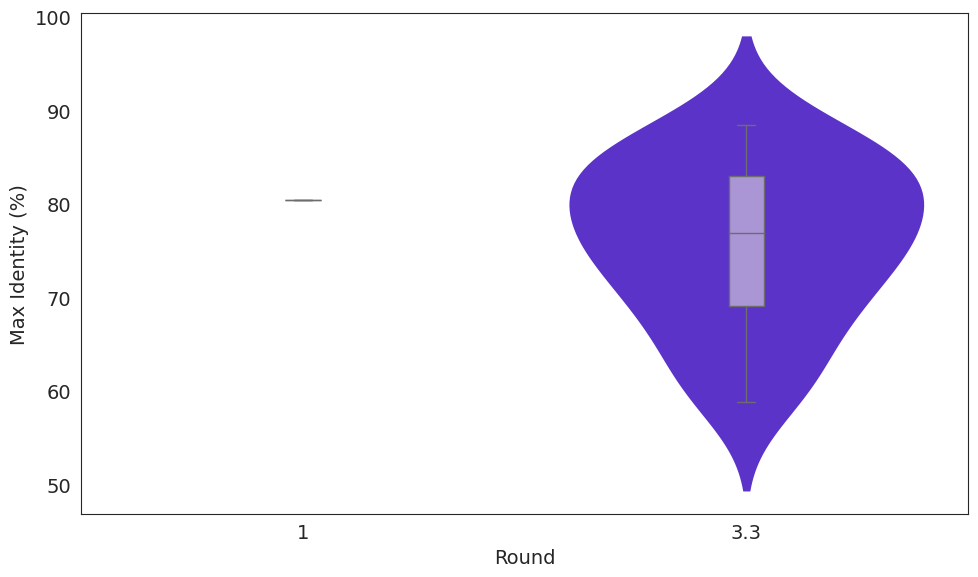

Done: plot_alignment_violin.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV (no header)
round3_3 = pd.read_csv("/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/VUR7E4Y6016-Alignment-HitTable.csv", header=None)
round1 = pd.read_csv("/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data/VUSS5YXB014-Alignment-HitTable(1).csv", header=None)

# Get max identity per sequence
round3_3.columns = ["name", "target", "identity"] + [f"col{i}" for i in range(3, round3_3.shape[1])]
round3_3 = round3_3.groupby("name")["identity"].max().reset_index()
round3_3["round"] = "3.3"

# Get max identity per sequence
round1.columns = ["name", "target", "identity"] + [f"col{i}" for i in range(3, round1.shape[1])]
round1 = round1.groupby("name")["identity"].max().reset_index()
round1["round"] = "1"

# Show the cleaned result with max identity per sequence
round1_max_identity.head()


df_max = pd.concat([round3_3, round1], ignore_index=True)

# Plot violin with orange/purple
colors = {"1": "#FFA500", "3.3": "#4F1AE1"}  # orange, purple
plt.figure(figsize=(10, 6))  # default for any standalone figures
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 14})

sns.violinplot(data=df_max, x="round", y="identity", order=["1", "3.3"], 
               hue="round", palette=colors, inner=None, legend=False, linewidth=0)
# Lighter shades for boxplots
box_colors = {"1": "#FFD699", "3.3": "#A88BE0"}  # light orange, light purple
sns.boxplot(data=df_max, x="round", y="identity", order=["1", "3.3"],
            hue="round", palette=box_colors, width=0.08, fliersize=0, legend=False)

plt.ylabel("Max Identity (%)")
plt.xlabel("Round")
plt.tight_layout()
plt.savefig("plots/plot_alignment_violin.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Done: plot_alignment_violin.pdf")


In [47]:
# Re-load the data and properly assign the columns based on your explanation
round1 = pd.read_csv(file_path, header=None)

# Assign correct column names
round1.columns = ["name", "target", "identity"] + [f"col{i}" for i in range(3, round1.shape[1])]

# Group by sequence name and get the maximum identity
round1_max_identity = round1.groupby("name")["identity"].max().reset_index()

# Add a round column
round1_max_identity["round"] = "1"

# Show the cleaned result with max identity per sequence
round1_max_identity.head()

NameError: name 'file_path' is not defined

In [31]:
round3_3

,name,identity,round
0,0,75.000,3.3
1,1,72.549,3.3
2,2,83.673,3.3
3,3,76.087,3.3
4,4,78.846,3.3
5,6,75.000,3.3
6,7,69.231,3.3
7,8,68.627,3.3
8,9,88.462,3.3
9,10,77.778,3.3
